In [7]:
import pandas as pd

df = pd.read_csv('/workspaces/employee-attrition/data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


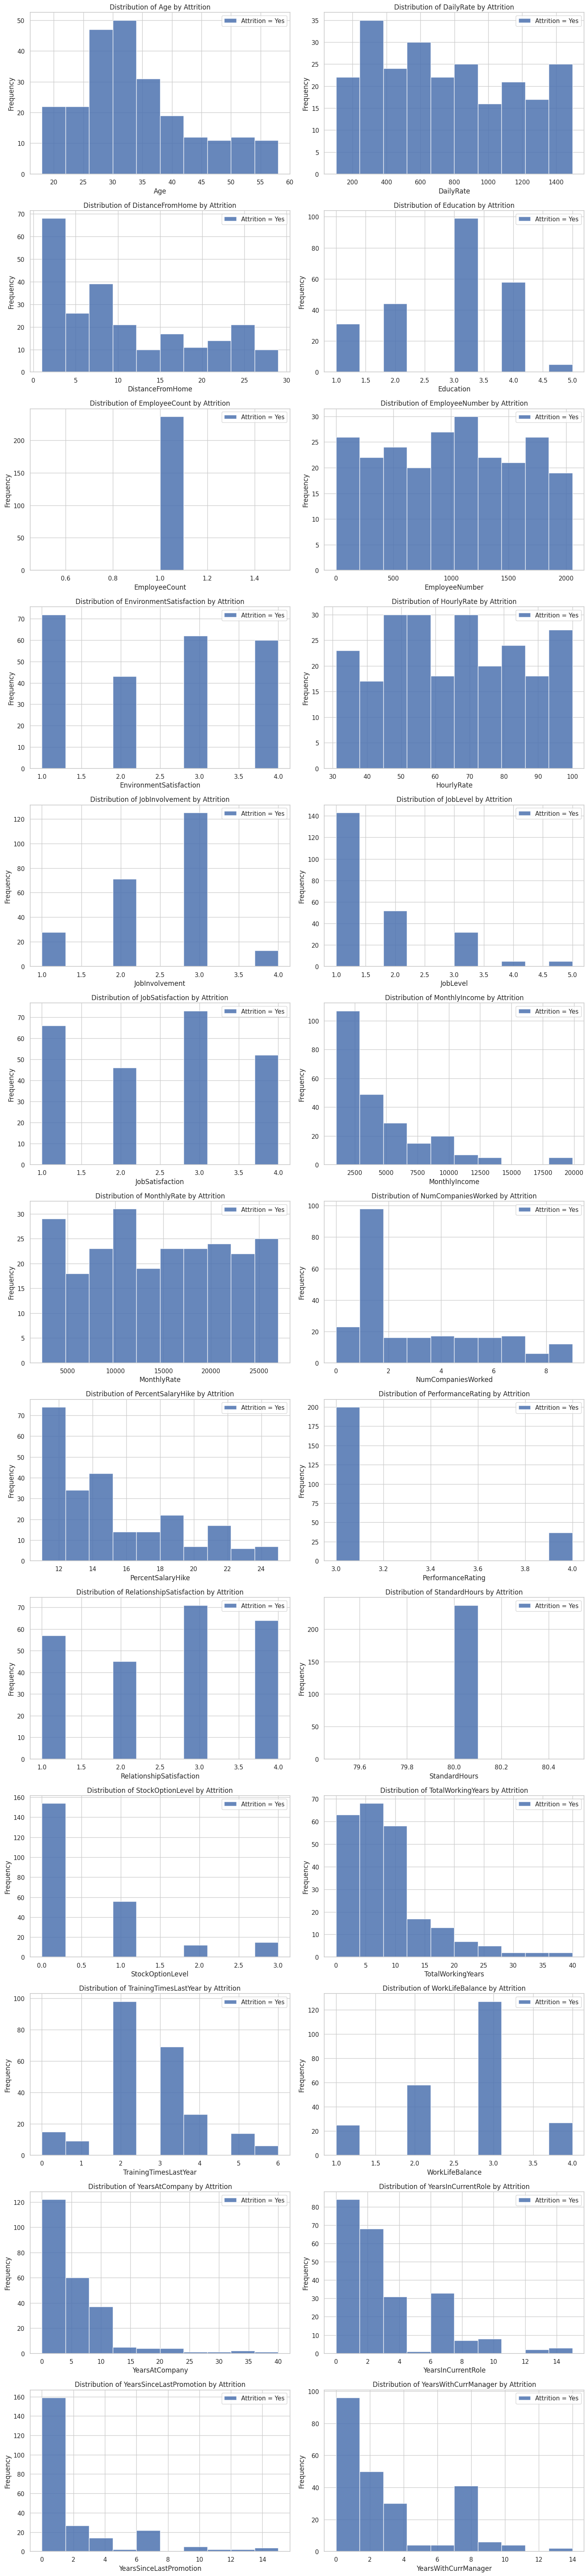

In [128]:
#make histogram distribution for each numeric column against the target variable 'Attrition'
import math
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_features = len(numeric_cols)

grid_cols = 2
grid_rows = math.ceil(num_features / grid_cols)

fig, axes = plt.subplots(
    nrows=grid_rows,
    ncols=grid_cols,
    figsize=(15, 5*grid_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    df[df['Attrition'] == 'Yes'][col].hist(alpha=0.85, label='Attrition = Yes', ax=ax)
    # df[df['Attrition'] == 'No'][col].hist(alpha=0.5, label='Attrition = No', ax=ax)

    ax.set_title(f'Distribution of {col} by Attrition')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

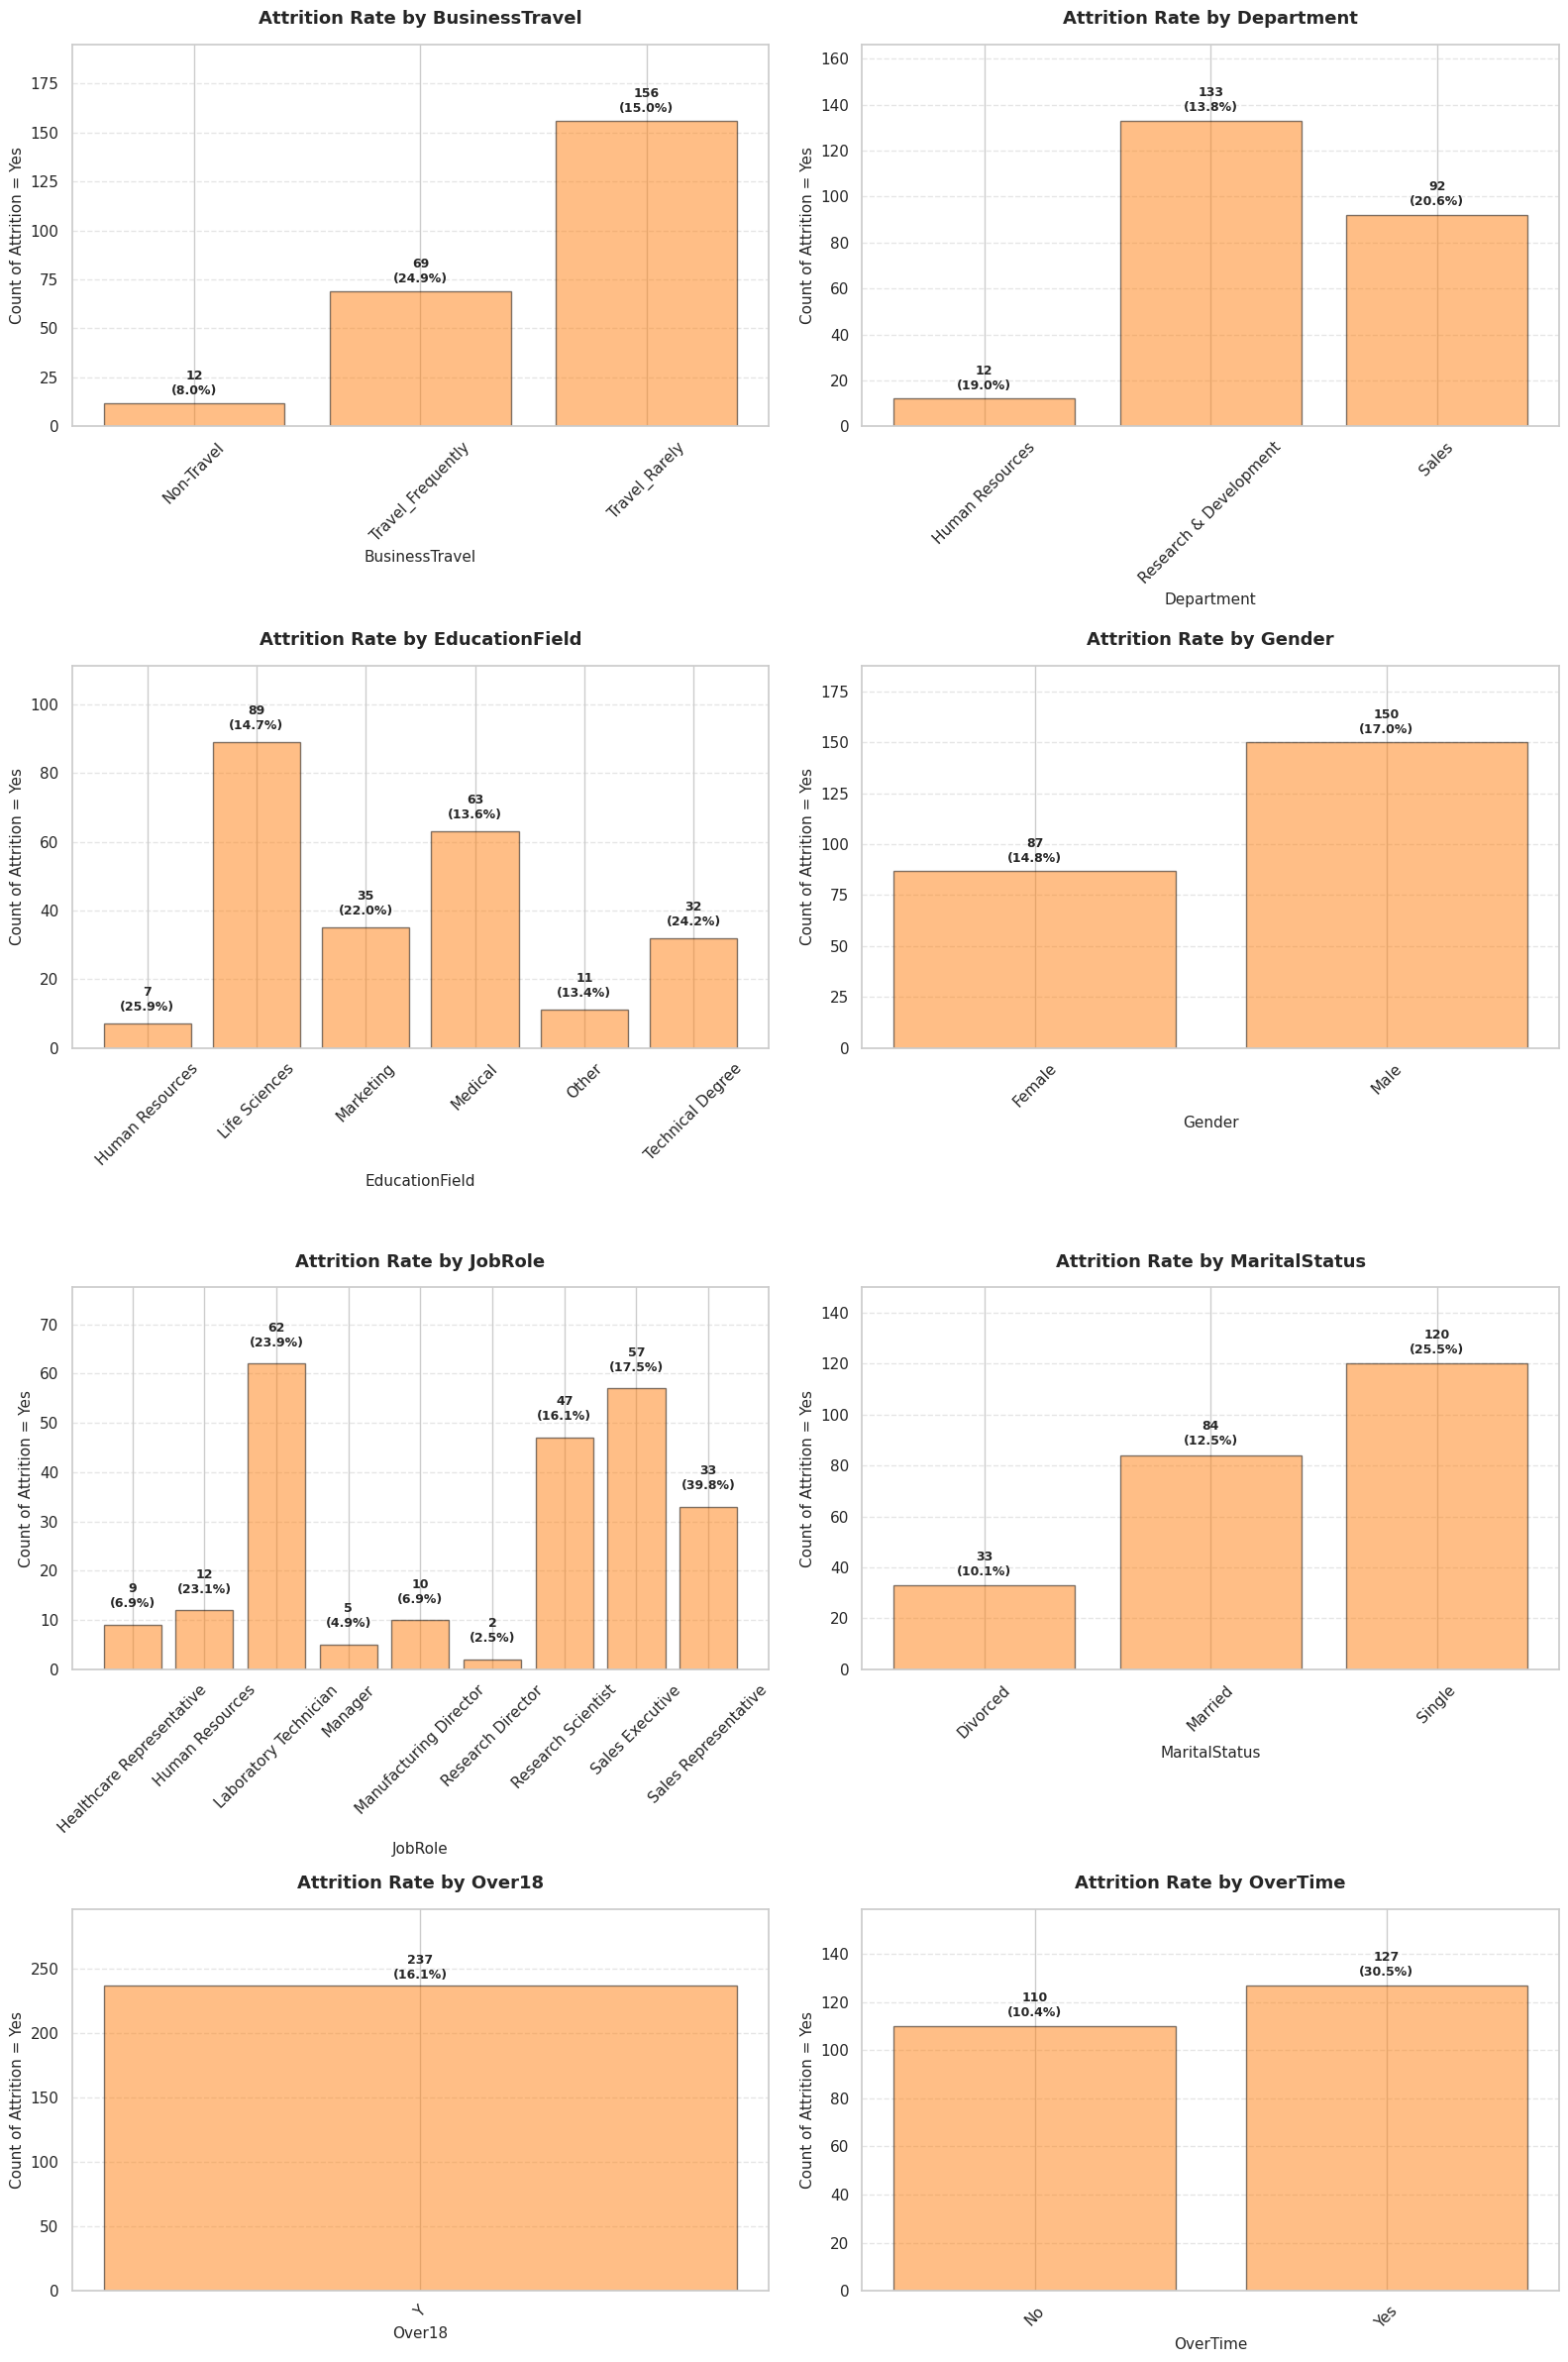

In [132]:
import math
import matplotlib.pyplot as plt

categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
if 'Attrition' in categorical_cols:
    categorical_cols.remove('Attrition')

num_features = len(categorical_cols)


num_grid_cols = 2
num_grid_rows = math.ceil(num_features / num_grid_cols)

fig, axes = plt.subplots(
    nrows=num_grid_rows, 
    ncols=num_grid_cols, 
    figsize=(16, 6 * num_grid_rows)
)
axes = axes.flatten()


for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
    
    total_counts = df.groupby(col).size()
    

    yes_counts = df[df['Attrition'] == 'Yes'].groupby(col).size()
    
    
    yes_counts = yes_counts.reindex(total_counts.index, fill_value=0)
    
    
    bars = ax.bar(yes_counts.index, yes_counts.values, color='#ff7f0e', alpha=0.5, edgecolor='black')
    
  
    for bar, category in zip(bars, yes_counts.index):
        height = bar.get_height()
        total = total_counts[category]
        
        
        percentage = (height / total) * 100 if total > 0 else 0
        
        
        label_text = f'{int(height)}\n({percentage:.1f}%)'
        
       
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height + (df.shape[0] * 0.002),  
            label_text, 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            weight='bold'
        )
    
    ax.set_title(f'Attrition Rate by {col}', fontsize=13, pad=15, weight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Count of Attrition = Yes', fontsize=11)
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    

    ax.set_ylim(0, yes_counts.max() * 1.25 if yes_counts.max() > 0 else 10)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [135]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']


In [136]:
y = y.map({'Yes': 1, 'No': 0})

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [152]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_cols)
    ],
    remainder='passthrough' # Kolom numerik akan dilewatkan tanpa diubah
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

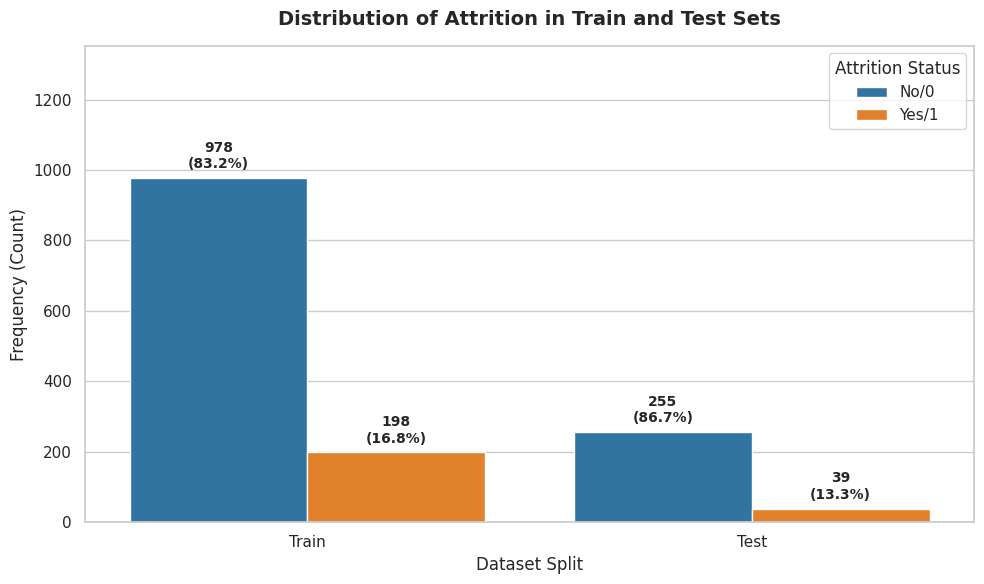

In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_train = pd.DataFrame({'Attrition': y_train, 'Dataset': 'Train'})
df_test = pd.DataFrame({'Attrition': y_test, 'Dataset': 'Test'})
df_combined = pd.concat([df_train, df_test])


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_combined,
    x='Dataset',
    hue='Attrition',
    palette={'No': '#1f77b4', 'Yes': '#ff7f0e'} if df_combined['Attrition'].dtype == 'object' else {0: '#1f77b4', 1: '#ff7f0e'}
)


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        current_x_label = ax.get_xticklabels()[int(p.get_x() + 0.4)].get_text()
        total_sample = len(y_train) if current_x_label == 'Train' else len(y_test)
        
        percentage = (height / total_sample) * 100
        label_text = f'{int(height)}\n({percentage:.1f}%)'
        # label_text = f'{int(height)}'
        
        ax.annotate(
            label_text,
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=10,
            weight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )


plt.title('Distribution of Attrition in Train and Test Sets', fontsize=14, pad=15, weight='bold')
plt.xlabel('Dataset Split', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.legend(title='Attrition Status', labels=['No/0', 'Yes/1'])

ax.set_ylim(0, max(len(y_train), len(y_test)) * 1.15)

plt.tight_layout()
plt.show()

In [155]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f'Original training set shape: {X_train.shape}, {y_train.shape}')
print(f'Resampled training set shape: {X_train_resampled.shape}, {y_train_resampled.shape}')

Original training set shape: (1176, 47), (1176,)
Resampled training set shape: (1956, 47), (1956,)


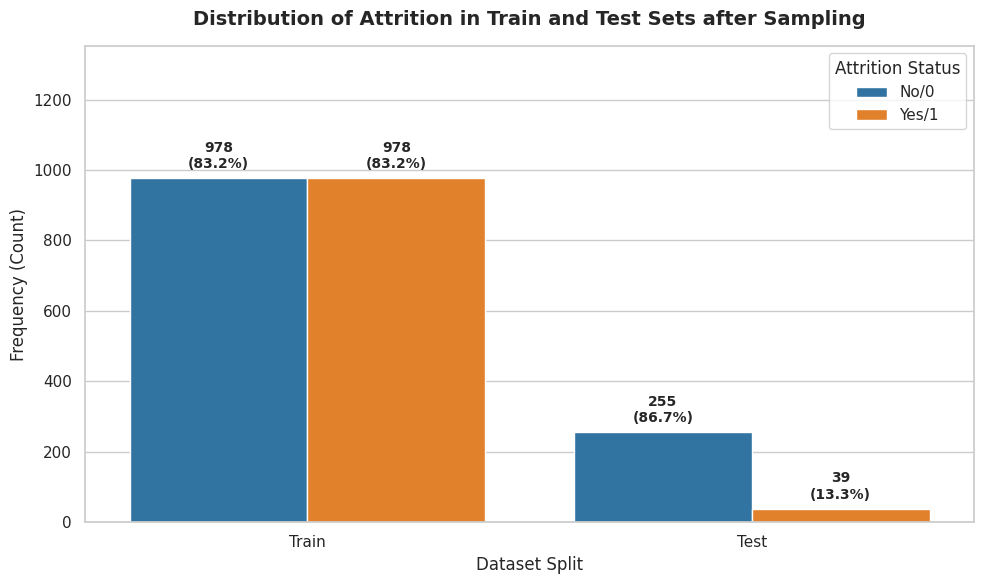

In [165]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_train = pd.DataFrame({'Attrition': y_train_resampled, 'Dataset': 'Train'})
df_test = pd.DataFrame({'Attrition': y_test, 'Dataset': 'Test'})
df_combined = pd.concat([df_train, df_test])


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_combined,
    x='Dataset',
    hue='Attrition',
    palette={'No': '#1f77b4', 'Yes': '#ff7f0e'} if df_combined['Attrition'].dtype == 'object' else {0: '#1f77b4', 1: '#ff7f0e'}
)


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        current_x_label = ax.get_xticklabels()[int(p.get_x() + 0.4)].get_text()
        total_sample = len(y_train) if current_x_label == 'Train' else len(y_test)
        
        percentage = (height / total_sample) * 100
        label_text = f'{int(height)}\n({percentage:.1f}%)'
        # label_text = f'{int(height)}'
        
        ax.annotate(
            label_text,
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=10,
            weight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )


plt.title('Distribution of Attrition in Train and Test Sets after Sampling' , fontsize=14, pad=15, weight='bold')
plt.xlabel('Dataset Split', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.legend(title='Attrition Status', labels=['No/0', 'Yes/1'])

ax.set_ylim(0, max(len(y_train), len(y_test)) * 1.15)

plt.tight_layout()
plt.show()

In [197]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.3]
}

scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb = XGBClassifier(n_estimators=100, objective='binary:logistic', random_state=42, scale_pos_weight=scale_pos)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='roc_auc', cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best AUC Score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=1, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=1, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=1, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=1, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=1, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=3, min_child_weight=1, subsample=0.8; total time=

Accuracy: 0.8877551020408163
Confusion Matrix:
 [[250   5]
 [ 28  11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       255
           1       0.69      0.28      0.40        39

    accuracy                           0.89       294
   macro avg       0.79      0.63      0.67       294
weighted avg       0.87      0.89      0.87       294



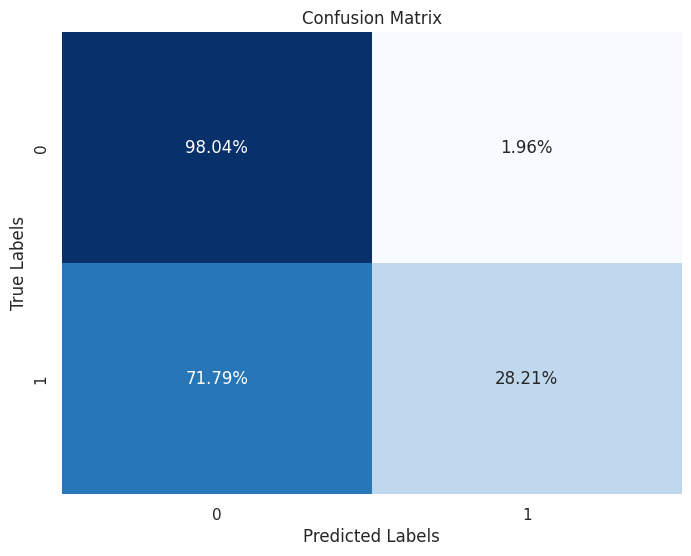

In [198]:
import numpy as np

model = XGBClassifier(**grid_search.best_params_, n_estimators=100, objective='binary:logistic', random_state=42)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
# y_pred_test = model.predict(X_test)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Print evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate normalized confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plotting the confusion matrix as percentages
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

/workspaces/employee-attrition/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [08:25:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eed" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8707482993197279
Confusion Matrix:
 [[246   9]
 [ 29  10]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.93       255
           1       0.53      0.26      0.34        39

    accuracy                           0.87       294
   macro avg       0.71      0.61      0.64       294
weighted avg       0.85      0.87      0.85       294



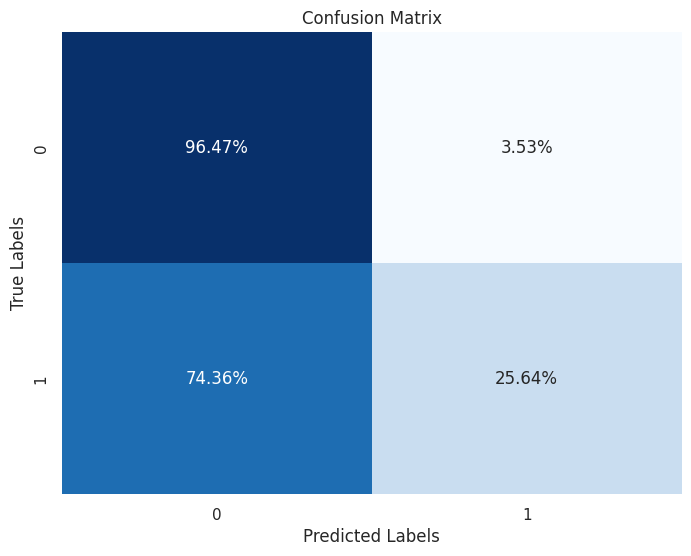

In [200]:
model = XGBClassifier(
    learning_rate =0.1, n_estimators=1000,
    max_depth=5, min_child_weight=1, gamma=0,subsample=0.8,colsample_bytree=0.8,
    objective= 'binary:logistic', nthread=4,eed=27)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Print evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate normalized confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plotting the confusion matrix as percentages
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()